# Case Study 3: Financial Fraud Detection

This notebook covers the following steps:

1. Check if the dataset includes required columns.
2. Load and preview the dataset.
3. Identify and handle class imbalance.
4. Perform anomaly detection.
5. Train Logistic Regression and Random Forest models.
6. Compare models using ROC and F1 Score.
7. Suggest fraud prevention strategies.


## 1. Check Dataset Columns

Verify that the dataset includes:

- Transaction amount
- Time
- User behavior
- Fraud label


In [1]:
# Step 1: Load and preview the dataset
import pandas as pd
df = pd.read_csv('datas/fraud_detection.csv')
print('Columns:', df.columns.tolist())
df.head()

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 2. Load and Preview Dataset

Read the CSV file into a pandas DataFrame and display the first few rows to understand the data structure.


Class distribution: {0: 6354407, 1: 8213}


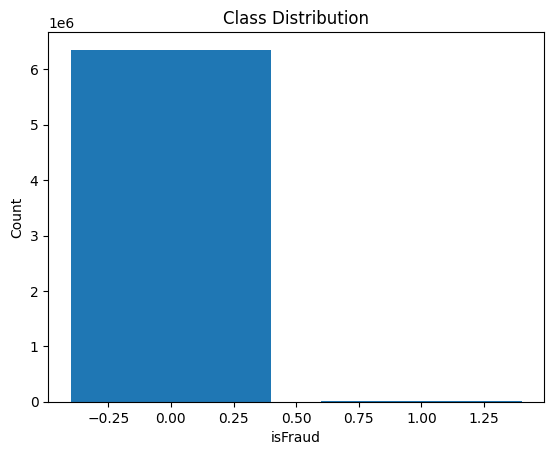

In [2]:
# Step 2: Check for class imbalance
import matplotlib.pyplot as plt
class_counts = df['isFraud'].value_counts()
print('Class distribution:', class_counts.to_dict())
plt.bar(class_counts.index, class_counts.values)
plt.xlabel('isFraud')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

## 3. Identify and Handle Class Imbalance

Analyze the distribution of the fraud label. If imbalance exists, apply techniques such as oversampling, undersampling, or SMOTE to balance the classes.


In [3]:
# Step 3: Handle class imbalance (optional, only if needed)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
X = df.drop(['isFraud', 'isFlaggedFraud'], axis=1).select_dtypes(include=['number'])
y = df['isFraud']
if abs(class_counts[0] - class_counts[1]) > 0.1 * len(df):
    print('Applying SMOTE to balance classes...')
    X_res, y_res = SMOTE(random_state=42).fit_resample(X, y)
else:
    print('Classes are balanced.')
    X_res, y_res = X, y

Applying SMOTE to balance classes...


## 4. Perform Anomaly Detection

Use statistical or machine learning methods (e.g., Isolation Forest, Local Outlier Factor) to detect anomalies in the dataset.


In [4]:
# Step 4: Anomaly detection using Isolation Forest
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_pred = iso_forest.fit_predict(X_scaled)
anomaly_count = (anomaly_pred == -1).sum()
print(f'Number of anomalies detected: {anomaly_count}')

Number of anomalies detected: 635441


## 5. Train Logistic Regression Model

Train a logistic regression model on the processed data and evaluate its performance.


In [5]:
# Step 5: Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]
print('Logistic Regression Classification Report:')
print(classification_report(y_test, y_pred_logreg))
print('ROC AUC:', roc_auc_score(y_test, y_proba_logreg))
print('F1 Score:', f1_score(y_test, y_pred_logreg))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93   1906309
           1       0.96      0.89      0.92   1906336

    accuracy                           0.92   3812645
   macro avg       0.93      0.92      0.92   3812645
weighted avg       0.93      0.92      0.92   3812645

ROC AUC: 0.9772706343342011
F1 Score: 0.9210997776513724


## 6. Train Random Forest Model

Train a random forest classifier on the same data and evaluate its performance.


In [6]:
# Step 6: Train Random Forest model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))
print('ROC AUC:', roc_auc_score(y_test, y_proba_rf))
print('F1 Score:', f1_score(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906309
           1       1.00      1.00      1.00   1906336

    accuracy                           1.00   3812645
   macro avg       1.00      1.00      1.00   3812645
weighted avg       1.00      1.00      1.00   3812645

ROC AUC: 0.9999908889467626
F1 Score: 0.9994673005929426


## 7. Compare Models Using ROC and F1 Score

Compare the performance of both models using ROC curves and F1 scores to determine which model performs better.


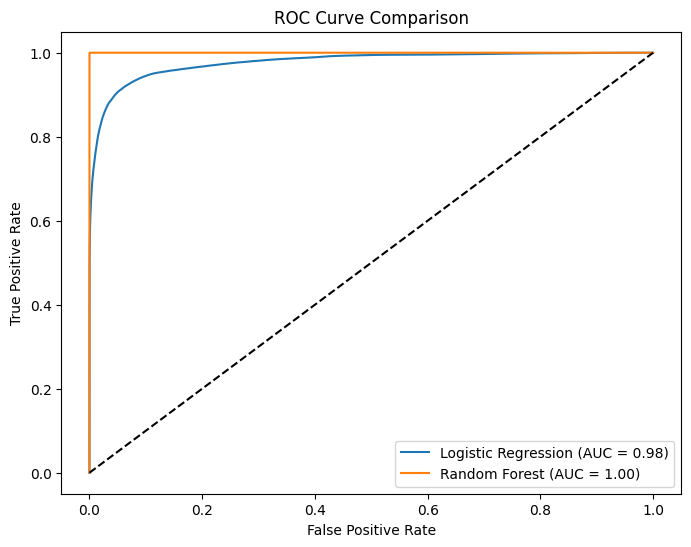

Logistic Regression F1 Score: 0.92
Random Forest F1 Score: 1.00


In [7]:
# Step 7: Compare models using ROC and F1 Score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {roc_auc_logreg:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()
print(f'Logistic Regression F1 Score: {f1_score(y_test, y_pred_logreg):.2f}')
print(f'Random Forest F1 Score: {f1_score(y_test, y_pred_rf):.2f}')

## 8. Suggest Fraud Prevention Strategies

Based on the analysis and model results, suggest actionable strategies for preventing financial fraud.


### Suggested Strategies

- Implement real-time transaction monitoring using trained models.
- Set up alerts for high-risk transactions or detected anomalies.
- Regularly retrain models with new data to adapt to evolving fraud patterns.
- Use multi-factor authentication for sensitive transactions.
- Educate users about common fraud tactics and prevention.
- Collaborate with other institutions to share fraud intelligence.
- Continuously evaluate and update fraud detection systems.
